In [1]:
import os
import torch
import pickle
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from rdkit import Chem
import json
import pandas as pd
import argparse
import sys
import random
import csv
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from rdkit.RDLogger import DisableLog
from CBTokenizer import CBTokenizer

# RDKit log banned
DisableLog('rdApp.*')


#set random seed
def set_seed(seed):
    """Set all possible random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# check molecule SMILES
def checkmol(pre_data):
    mols = pre_data.squence
    labels = pre_data.labels
    print('Original {} has {} data, start checking'.format(pre_data.args.dataset, len(mols)))

    valid_mols = []  
    valid_labels = []  

    for i in range(len(mols)):
        if mols[i] == "":
            continue
        mol = Chem.MolFromSmiles(mols[i])
        if mol is not None:
            # rdkit 检测分子正确性
            mol = Chem.MolToSmiles(mol, canonical=True, kekuleSmiles=False)
            valid_mols.append(mol)
            valid_labels.append(int(labels[i]))

    # 提取表达式和标签
    data = [[mol, label] for mol, label in zip(valid_mols, valid_labels)]
    print('Finish checking molecules, now {} has {} data'.format(pre_data.args.dataset, len(data)))
    return data




# split data
def data_split(post_data,args,status=False):
    '''status: get detail or not
    '''
    labels = [label for input_ids, attention_mask, label in post_data]

    train_val_data, test_data, train_val_labels, test_labels = train_test_split(
        post_data, labels, test_size=0.1, stratify=labels, random_state=args.seed
    )

    train_data, val_data, train_labels, val_labels = train_test_split(
        train_val_data, train_val_labels, test_size=1/9, stratify=train_val_labels, random_state=args.seed
    )
    
    if status == True:
        def count_class_distribution(data):
            counts = {0: 0, 1: 0}
            for _, label in data:
                counts[label] += 1
            return counts
        train_distribution = count_class_distribution(train_data)
        val_distribution = count_class_distribution(val_data)
        test_distribution = count_class_distribution(test_data)

        print("Train set class distribution:", train_distribution)
        print("Validation set class distribution:", val_distribution)
        print("Test set class distribution:", test_distribution)
    return train_data,val_data,test_data


# args to select dataset and seed
def create_args(dataset,name='modelname',seed=42):

    sys.argv = sys.argv[:1] + [arg for arg in sys.argv[1:] if not arg.startswith('--f=')]

    parser = argparse.ArgumentParser(description='Process some integers.')
    parser.add_argument('--dataset', type=str, default=dataset,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--name', type=str, default=name,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--seed', type=int, default=seed)
    args = parser.parse_args()
    return args

# process raw data (from MolR)
class PropertyPreData():
    def __init__(self, args):
        self.args = args
        self.path = './data/data_MoIR/' + args.dataset
        self.squence = []
        self.labels = []

    def process(self):
        print('processing ' + self.args.dataset+ ' dataset')
        with open(self.path + '.csv') as f:
            for idx, line in enumerate(f.readlines()):
                if idx == 0 or line == '\n':
                    continue
                items = line.strip().split(',')
                if self.args.dataset == 'BBBP':
                    smiles, label = items[-1], items[-2]
                    # the next line is to remove unnecessary hydrogen atoms that will cause discontinuous node labels
                    smiles = smiles.replace('([H])', '').replace('[H]', '')
                elif self.args.dataset == 'HIV':
                    smiles, label = items[0], items[-1]
                    smiles = smiles.replace('se', 'Se').replace('te', 'Te')
                elif self.args.dataset == 'BACE':
                    smiles, label = items[0], items[2]
                elif self.args.dataset == 'Tox21':
                    smiles, label = items[-1], items[11]
                    smiles = smiles.replace('se', 'Se')
                    if label == '':
                        continue
                elif self.args.dataset == 'ClinTox':
                    smiles, label = items[0], items[2]
                    smiles = smiles.replace('[H]', '')
                else:
                    raise ValueError('unknown dataset')
                self.squence.append(smiles)
                self.labels.append(float(label))


# convert SMILES to token
def preprocess_and_save_data(data, save_path, tokenizer):
    #difine length of tensor =  max(len(SMILES))+2
    max_smiles_length = max(len(smiles) for smiles, _ in data)
    maxlen = max_smiles_length + 2
    processed_data = []
    failed_data = []
    for smiles, label in data:
        try:
            encoded = tokenizer.encoder(smiles, alllen = maxlen, no0mode = False)
            processed_data.append((encoded["input_ids"], encoded["attention_mask"], label))
        except Exception as e:
            #print(f"Failed to encode SMILES: {smiles}, Error: {e}")
            failed_data.append((smiles, label))
    with open(save_path, 'wb') as f:
        pickle.dump(processed_data, f)
    print(f"maxlen : {maxlen}")
    print(f"final data {len(processed_data)}")
    print(f"Data saved to {save_path}")
    if failed_data:
        failed_save_path = save_path.replace('.pkl', '_failed.csv')
        with open(failed_save_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['SMILES', 'Label'])
            writer.writerows(failed_data)
        print(f"Failed data saved to {failed_save_path}")

RDKit WARNING: [22:30:14] Enabling RDKit 2019.09.3 jupyter extensions
[22:30:14] Enabling RDKit 2019.09.3 jupyter extensions


In [3]:

# tokenize molecule & save tokened data
datasets = ['BBBP', 'HIV', 'BACE', 'Tox21', 'ClinTox']
for i, dataset in enumerate(datasets):
    args = create_args(dataset, f'{dataset}')
    pre_data = PropertyPreData(args)
    pre_data.process()
    post_data = checkmol(pre_data)
    for item in post_data:
        item[1] = float(item[1])

    preprocess_save_path = f"./preprocessed_data_test/{args.name}.pkl"
    os.makedirs(os.path.dirname(preprocess_save_path), exist_ok=True)

    if not os.path.exists(preprocess_save_path):
        tokenizer = CBTokenizer()
        preprocess_and_save_data(post_data, preprocess_save_path, tokenizer)


processing BBBP dataset
Original BBBP has 2050 data, start checking
Finish checking molecules, now BBBP has 2039 data
processing HIV dataset
Original HIV has 41127 data, start checking
Finish checking molecules, now HIV has 41127 data
processing BACE dataset
Original BACE has 1513 data, start checking
Finish checking molecules, now BACE has 1513 data
processing Tox21 dataset
Original Tox21 has 6909 data, start checking
Finish checking molecules, now Tox21 has 6909 data
processing ClinTox dataset
Original ClinTox has 1484 data, start checking
Finish checking molecules, now ClinTox has 1476 data


In [7]:
tokenizer = CBTokenizer()
smiles = 'O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2ccccc2C)C)CC1(C)C'
encoded = tokenizer.encoder(smiles, alllen = 100, no0mode = False)
encoded["input_ids"]

tensor([  1, 120,  19, 118, 118,   6, 118,   8,   8, 113,   7,  12, 119, 118,
         12,  16, 120,  13,   6, 118,   8,   8, 113,   7,  12, 118, 108,  20,
        108, 108,  21, 108, 108,  12, 108, 108, 108,  21, 110, 108,  20, 119,
         13,  10, 108,  20, 108, 108, 108, 108, 108,  20, 118,  13, 118,  13,
        118, 118,  19,  12, 118,  13, 118,   3,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0])

## training

In [ ]:
from CBmodel4prediction import *

def load_preprocessed_data(load_path):
    with open(load_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Data loaded from {load_path}")
    return data

def train(args, pretrain_model='model_1200'):
    set_seed(args.seed)
    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    train_data,val_data,test_data = data_split(preprocessed_data,args,status=False)
    #data = train_data + val_data
    
    print('train:val:test = {}:{}:{}'.format(len(train_data),len(val_data),len(test_data)))
   
    # 实例化新模型
    c = MolProperty(
        out_type=2,
        name=args.name,
        pre_model=pretrain_model,
        device="cuda:0",
        epoch_stop=5
    )
    print('start tarining!')
    #c.batchtrain(data, 50, int(len(data)*8/9), int(len(data)*1/9), te=0, batch_size = 4)
    c.batchtrain2(train_data,val_data, epoch=50, batch_size=4)
    print('finish tarining!!!')


def test(args):
    # 实例化新模型
    c = MolProperty(
        out_type=2,
        name=args.name,
        pre_model='model_1200',
        device="cuda:0"
    )
    set_seed(args.seed)

    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)

    _, _, test_data = data_split(preprocessed_data, args)
    c.test(test_data)



[2025-07-10 22:38:22,551] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH
 [WARNING]  please install triton==1.0.0 if you want to use sparse attention


In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np


def train_with_cv(args, pretrain_model='model_1200'):
    """执行分层k折交叉验证训练"""
    set_seed(args.seed)  # 设置全局随机种子
    
    # 加载数据
    preprocess_save_path = f"./preprocessed_data/{args.dataset}.pkl"
    preprocessed_data = load_preprocessed_data(preprocess_save_path)
    
    # 解压数据
    all_smiles, all_attention_masks, all_labels = zip(*preprocessed_data)
    all_labels = np.array(all_labels)  # 转换为数组便于统计
    
    skf = StratifiedKFold(n_splits=args.n_splits, shuffle=True, random_state=args.seed)
    fold_accuracies = []
    fold_aucs = []
    
    print(f"Start {args.n_splits}-fold cross-validation for dataset {args.dataset}")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(all_smiles, all_labels)):
        print(f"\n--- Fold {fold + 1} ---")
        
        # 打印类别分布
        print("Train class distribution:", np.bincount(all_labels[train_idx]))
        print("Validation class distribution:", np.bincount(all_labels[val_idx]))
        
        # 直接使用索引访问数据 (避免复制)
        train_data = [preprocessed_data[i] for i in train_idx]
        val_data = [preprocessed_data[i] for i in val_idx]
        
        # 实例化模型并加载预训练权重
        model = MolProperty(
            out_type=2,
            name=f"{args.name}_fold{fold+1}",
            pre_model=pretrain_model,  # 加载预训练权重
            device=args.device,         # 使用args中的设备
            epoch_stop=5
        )
        
        # 训练与验证
        print('Start training!')
        model.batchtrain2(train_data, val_data, epoch=50, batch_size=4)
        print('Finish training!')
        
        print('Start validation!')
        acc, auc = model.test(val_data)
        fold_accuracies.append(acc)
        fold_aucs.append(auc)
        print(f"Fold {fold+1} - Accuracy: {acc:.4f}, AUC: {auc:.4f}")
    
    # 计算平均性能
    mean_acc = np.mean(fold_accuracies)
    mean_auc = np.mean(fold_aucs)
    std_acc = np.std(fold_accuracies)
    std_auc = np.std(fold_aucs)
    
    print("\n=== Final Results ===")
    print(f"Average Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Average AUC: {mean_auc:.4f} ± {std_auc:.4f}")
    
    # 保存结果到文件
    results = {
        "accuracies": fold_accuracies,
        "aucs": fold_aucs,
        "mean_accuracy": mean_acc,
        "mean_auc": mean_auc,
        "std_accuracy": std_acc,
        "std_auc": std_auc
    }
    
    result_file = f"./results/{args.name}_{args.dataset}_cv_results.json"
    os.makedirs(os.path.dirname(result_file), exist_ok=True)
    with open(result_file, 'w') as f:
        json.dump(results, f, indent=4)
    
    return results

## ClinTox

Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 85.94586148113012, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 67.81918130069971, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 56.22067057527602, Train Acc: 0.9271186440677966
Validation Acc: 0.9324324324324325, Val Count: 148
Model saved!
Epoch 3
Train Loss: 47.424304105341434, Train Acc: 0.9415254237288135
Validation Acc: 0.9324324324324325, Val Count: 148
Epoch 4
Train Loss: 36.94539640843868, Train Acc: 0.9550847457627119
Validation Acc: 0.9391891891891891, Val Count: 148
Model saved!
Epoch 5
Train Loss: 33.617512537166476, Train Acc: 0.9601694915254237
Validation Acc: 0.9324324324324325, Val Count: 148
Epoch 6
Train Loss: 25.997958997264504, Train Acc: 0.9669491525423729
Validation Acc: 

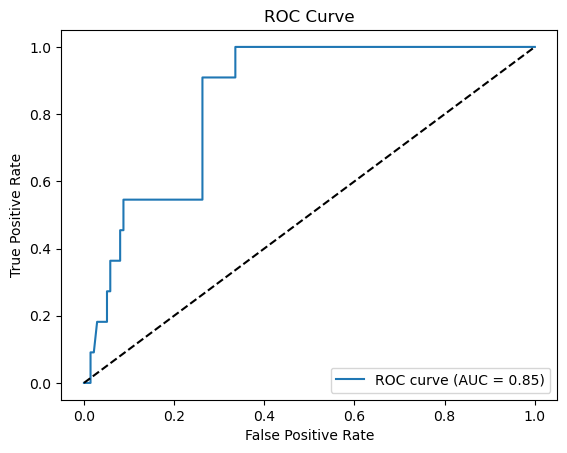

Test Accuracy: 0.9121621621621622, AUC: 0.845056403450564
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 87.10306426882744, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 67.7162523791194, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 52.266968846321106, Train Acc: 0.9296610169491526
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 3
Train Loss: 41.95758113451302, Train Acc: 0.9449152542372882
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 4
Train Loss: 32.594395242631435, Train Acc: 0.9576271186440678
Validation Acc: 0.918918918918919, Val Count: 148
Epoch 5
Train Loss: 27.289003159850836, Train Acc: 0.9720338983050848
Validation Acc: 0.9121621621621622, Val Count: 148
No improvement in the last 5 epochs. Training stopped.


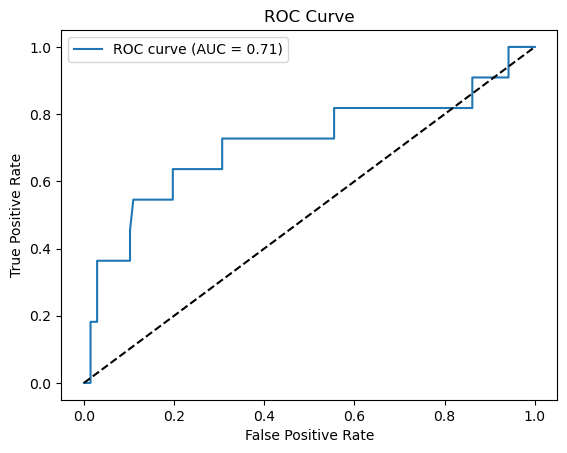

Test Accuracy: 0.9256756756756757, AUC: 0.7130059721300598
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 81.68478836119175, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 63.84917226806283, Train Acc: 0.923728813559322
Validation Acc: 0.9324324324324325, Val Count: 148
Model saved!
Epoch 2
Train Loss: 52.56437200307846, Train Acc: 0.9313559322033899
Validation Acc: 0.9459459459459459, Val Count: 148
Model saved!
Epoch 3
Train Loss: 41.909967517480254, Train Acc: 0.9432203389830508
Validation Acc: 0.9324324324324325, Val Count: 148
Epoch 4
Train Loss: 34.700050039216876, Train Acc: 0.9576271186440678
Validation Acc: 0.9391891891891891, Val Count: 148
Epoch 5
Train Loss: 29.994292960502207, Train Acc: 0.9601694915254237
Validation Acc: 0.9459459459459459, Val Count: 148
Epoch 6
Train Loss: 24.048

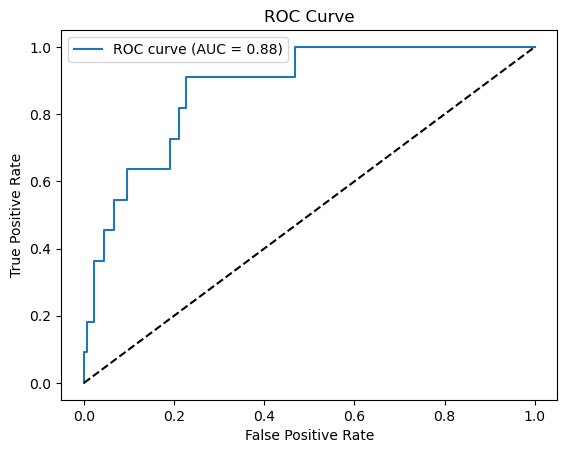

Test Accuracy: 0.9256756756756757, AUC: 0.8772395487723955


In [14]:
for i in range(2025,2028):
    args = create_args('ClinTox','ClinTox'+str(i),i)
    train(args,pretrain_model='model_1200')
    test(args)

Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 81.96669963747263, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 77.56568560749292, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 73.59038393944502, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 3
Train Loss: 70.23939788900316, Train Acc: 0.9220338983050848
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 4
Train Loss: 64.68474497459829, Train Acc: 0.9245762711864407
Validation Acc: 0.9324324324324325, Val Count: 148
Model saved!
Epoch 5
Train Loss: 61.650957483798265, Train Acc: 0.9305084745762712
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 6
Train Loss: 60.66823179833591, Train Acc: 0.9279661016949152
Validation Acc: 0.9324324324324325, Val Co

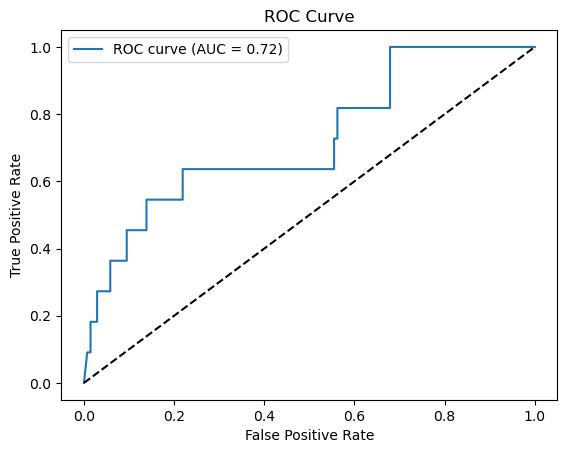

Test Accuracy: 0.9256756756756757, AUC: 0.7242866622428666
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 81.53595000877976, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 79.21406311914325, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 75.68674705550075, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 3
Train Loss: 73.05695644393563, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 4
Train Loss: 68.0309082660824, Train Acc: 0.9228813559322034
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 5
Train Loss: 64.99706034734845, Train Acc: 0.9245762711864407
Validation Acc: 0.9256756756756757, Val Count: 148
No improvement in the last 5 epochs. Training stopped.
finish tarini

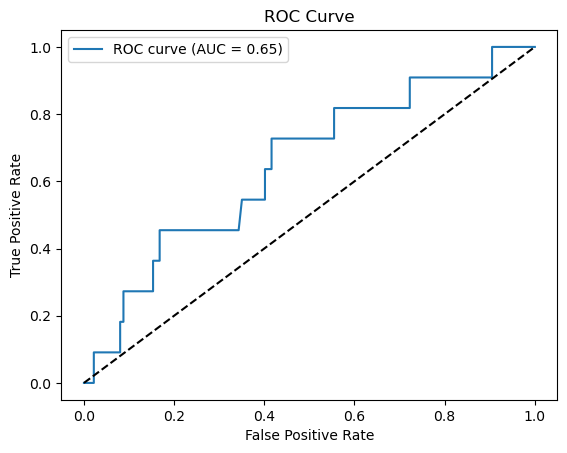

Test Accuracy: 0.9256756756756757, AUC: 0.6493032514930326
Data loaded from ./preprocessed_data/ClinTox.pkl
train:val:test = 1180:148:148
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 81.35376345738769, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Model saved!
Epoch 1
Train Loss: 78.40523575246334, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 2
Train Loss: 75.91656244546175, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 3
Train Loss: 70.36889582499862, Train Acc: 0.923728813559322
Validation Acc: 0.9256756756756757, Val Count: 148
Epoch 4
Train Loss: 66.02890456654131, Train Acc: 0.9245762711864407
Validation Acc: 0.9121621621621622, Val Count: 148
Epoch 5
Train Loss: 63.7934514824301, Train Acc: 0.9254237288135593
Validation Acc: 0.9256756756756757, Val Count: 148
No improvement in the last 5 epochs. Training stopped.
finish tarini

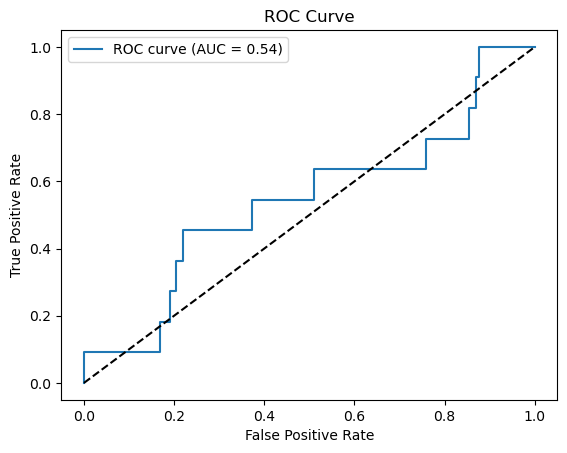

Test Accuracy: 0.9256756756756757, AUC: 0.5434638354346384


In [15]:
for i in range(2025,2028):
    args = create_args('ClinTox','Random_ClinTox'+str(i),i)
    train(args,pretrain_model=' ')
    test(args)

## BACE

Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 189.51953145861626, Train Acc: 0.6542597187758478
Validation Acc: 0.7763157894736842, Val Count: 152
Model saved!
Epoch 1
Train Loss: 150.1670392602682, Train Acc: 0.7857733664185277
Validation Acc: 0.7828947368421053, Val Count: 152
Model saved!
Epoch 2
Train Loss: 129.44856937229633, Train Acc: 0.8163771712158809
Validation Acc: 0.8026315789473685, Val Count: 152
Model saved!
Epoch 3
Train Loss: 116.65436853468418, Train Acc: 0.8395368072787428
Validation Acc: 0.8289473684210527, Val Count: 152
Model saved!
Epoch 4
Train Loss: 103.36909364163876, Train Acc: 0.8660049627791563
Validation Acc: 0.7960526315789473, Val Count: 152
Epoch 5
Train Loss: 100.86100097000599, Train Acc: 0.8676592224979321
Validation Acc: 0.8157894736842105, Val Count: 152
Epoch 6
Train Loss: 90.5217742845416, Train Acc: 0.8808933002481389
Val

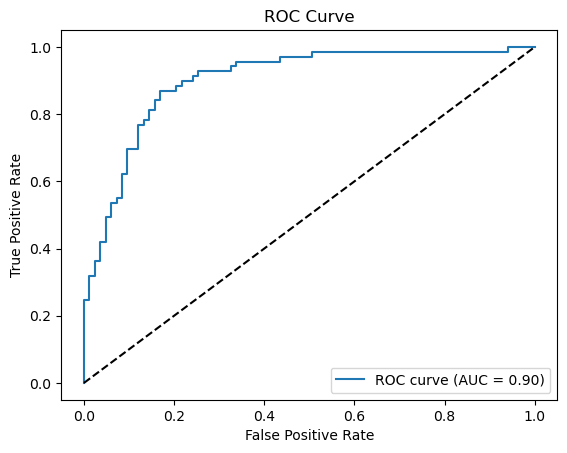

Test Accuracy: 0.7960526315789473, AUC: 0.9013445084686573
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 189.1853938549757, Train Acc: 0.6683209263854425
Validation Acc: 0.756578947368421, Val Count: 152
Model saved!
Epoch 1
Train Loss: 153.85096041858196, Train Acc: 0.7675765095119934
Validation Acc: 0.8026315789473685, Val Count: 152
Model saved!
Epoch 2
Train Loss: 130.0617518350482, Train Acc: 0.8205128205128205
Validation Acc: 0.7697368421052632, Val Count: 152
Epoch 3
Train Loss: 118.15112628042698, Train Acc: 0.8362282878411911
Validation Acc: 0.8157894736842105, Val Count: 152
Model saved!
Epoch 4
Train Loss: 104.75599447637796, Train Acc: 0.8560794044665012
Validation Acc: 0.8092105263157895, Val Count: 152
Epoch 5
Train Loss: 96.42326652258635, Train Acc: 0.8767576509511993
Validation Acc: 0.7960526315789473, Val Count: 152
Epoch 6
Train Loss: 91.15893

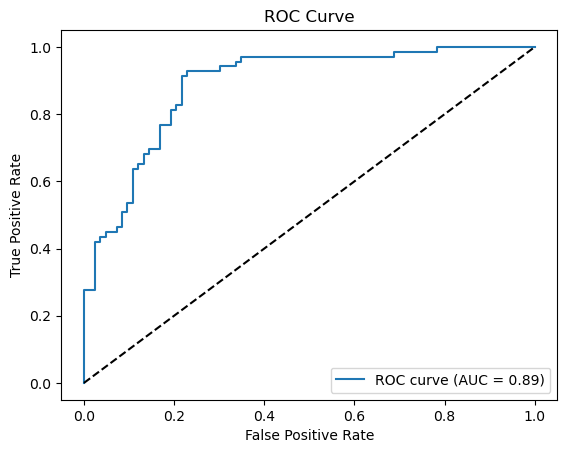

Test Accuracy: 0.8355263157894737, AUC: 0.8877248122926489
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 190.8969505727291, Train Acc: 0.6542597187758478
Validation Acc: 0.7236842105263158, Val Count: 152
Model saved!
Epoch 1
Train Loss: 149.38954623043537, Train Acc: 0.7874276261373035
Validation Acc: 0.8092105263157895, Val Count: 152
Model saved!
Epoch 2
Train Loss: 127.91813055425882, Train Acc: 0.8246484698097601
Validation Acc: 0.8092105263157895, Val Count: 152
Epoch 3
Train Loss: 113.14280238002539, Train Acc: 0.858560794044665
Validation Acc: 0.7894736842105263, Val Count: 152
Epoch 4
Train Loss: 101.50130665302277, Train Acc: 0.8759305210918115
Validation Acc: 0.7763157894736842, Val Count: 152
Epoch 5
Train Loss: 93.61946550756693, Train Acc: 0.8784119106699751
Validation Acc: 0.7960526315789473, Val Count: 152
Epoch 6
Train Loss: 84.69484921172261, T

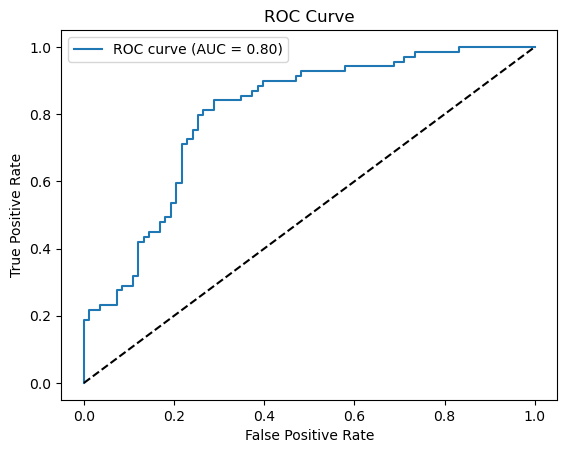

Test Accuracy: 0.7697368421052632, AUC: 0.8019905709795704


In [16]:
for i in range(2025,2028):
    args = create_args('BACE','BACE'+str(i),i)
    train(args,pretrain_model='model_1200')
    test(args)

Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 204.62504628300667, Train Acc: 0.564929693961952
Validation Acc: 0.6776315789473685, Val Count: 152
Model saved!
Epoch 1
Train Loss: 196.68945252895355, Train Acc: 0.6162117452440034
Validation Acc: 0.743421052631579, Val Count: 152
Model saved!
Epoch 2
Train Loss: 181.818241417408, Train Acc: 0.674110835401158
Validation Acc: 0.7236842105263158, Val Count: 152
Epoch 3
Train Loss: 175.03392978012562, Train Acc: 0.706368899917287
Validation Acc: 0.6776315789473685, Val Count: 152
Epoch 4
Train Loss: 164.53152273595333, Train Acc: 0.7419354838709677
Validation Acc: 0.7105263157894737, Val Count: 152
Epoch 5
Train Loss: 162.94457034766674, Train Acc: 0.727874276261373
Validation Acc: 0.6907894736842105, Val Count: 152
Epoch 6
Train Loss: 163.11740746349096, Train Acc: 0.728701406120761
Validation Acc: 0.6578947368421053, Val Coun

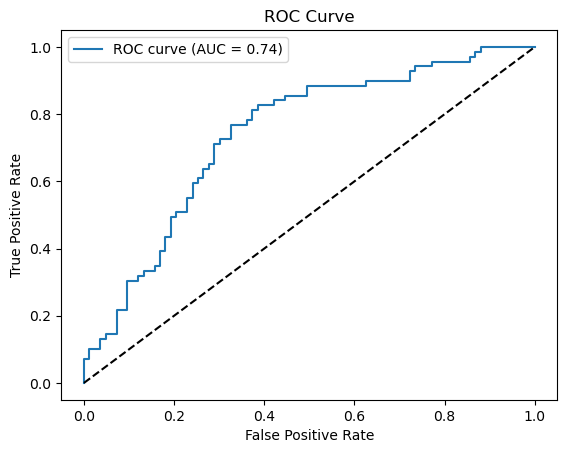

Test Accuracy: 0.6907894736842105, AUC: 0.7398288807403528
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 205.67379266023636, Train Acc: 0.5583126550868487
Validation Acc: 0.5723684210526315, Val Count: 152
Model saved!
Epoch 1
Train Loss: 198.54041704535484, Train Acc: 0.6253101736972705
Validation Acc: 0.7302631578947368, Val Count: 152
Model saved!
Epoch 2
Train Loss: 187.23787534236908, Train Acc: 0.6583953680727874
Validation Acc: 0.7171052631578947, Val Count: 152
Epoch 3
Train Loss: 181.80561858415604, Train Acc: 0.674937965260546
Validation Acc: 0.7171052631578947, Val Count: 152
Epoch 4
Train Loss: 169.93202494084835, Train Acc: 0.7162944582299421
Validation Acc: 0.7302631578947368, Val Count: 152
Epoch 5
Train Loss: 166.9777528643608, Train Acc: 0.7253928866832092
Validation Acc: 0.7763157894736842, Val Count: 152
Model saved!
Epoch 6
Train Loss: 161.987003535032

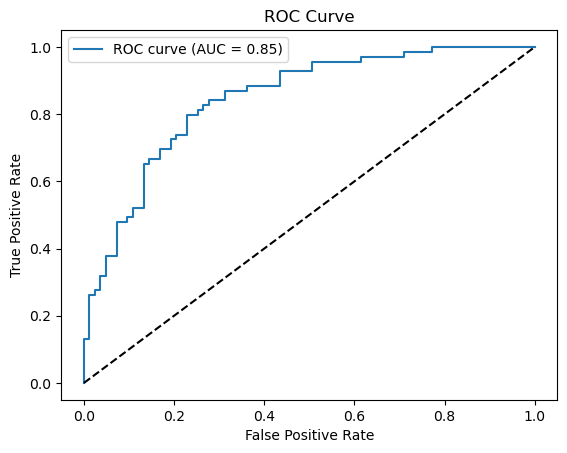

Test Accuracy: 0.7697368421052632, AUC: 0.8459926663174436
Data loaded from ./preprocessed_data/BACE.pkl
train:val:test = 1209:152:152
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 205.6068468093872, Train Acc: 0.5599669148056244
Validation Acc: 0.6842105263157895, Val Count: 152
Model saved!
Epoch 1
Train Loss: 190.32577994465828, Train Acc: 0.6484698097601324
Validation Acc: 0.7236842105263158, Val Count: 152
Model saved!
Epoch 2
Train Loss: 180.17707842588425, Train Acc: 0.6699751861042184
Validation Acc: 0.743421052631579, Val Count: 152
Model saved!
Epoch 3
Train Loss: 169.43493416905403, Train Acc: 0.71712158808933
Validation Acc: 0.7302631578947368, Val Count: 152
Epoch 4
Train Loss: 164.4966901242733, Train Acc: 0.7369727047146402
Validation Acc: 0.7368421052631579, Val Count: 152
Epoch 5
Train Loss: 161.72686350345612, Train Acc: 0.7444168734491315
Validation Acc: 0.756578947368421, Val Count: 152
Model saved!
Epoch 6
Train Loss: 156.318

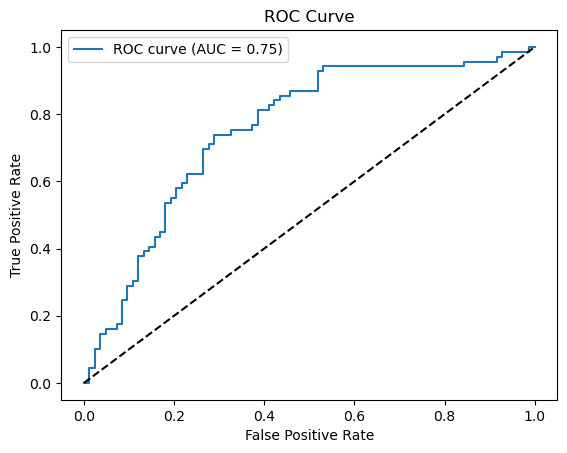

Test Accuracy: 0.6907894736842105, AUC: 0.7544962458529773


In [23]:
for i in range(2025,2028):
    args = create_args('BACE','Random_BACE'+str(i),i)
    train(args,pretrain_model=' ')
    test(args)

## BBBP

Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 181.9522326812148, Train Acc: 0.7958307786633967
Validation Acc: 0.8480392156862745, Val Count: 204
Model saved!
Epoch 1
Train Loss: 129.35830640792847, Train Acc: 0.8767627222562845
Validation Acc: 0.8676470588235294, Val Count: 204
Model saved!
Epoch 2
Train Loss: 110.57275131717324, Train Acc: 0.9012875536480687
Validation Acc: 0.8774509803921569, Val Count: 204
Model saved!
Epoch 3
Train Loss: 94.11754702404141, Train Acc: 0.9153893316983446
Validation Acc: 0.8774509803921569, Val Count: 204
Epoch 4
Train Loss: 80.74922129511833, Train Acc: 0.9282648681790313
Validation Acc: 0.8627450980392157, Val Count: 204
Epoch 5
Train Loss: 68.84371349960566, Train Acc: 0.9423666462293072
Validation Acc: 0.8627450980392157, Val Count: 204
Epoch 6
Train Loss: 57.66081554070115, Train Acc: 0.9564684242795831
Validation Acc: 0.

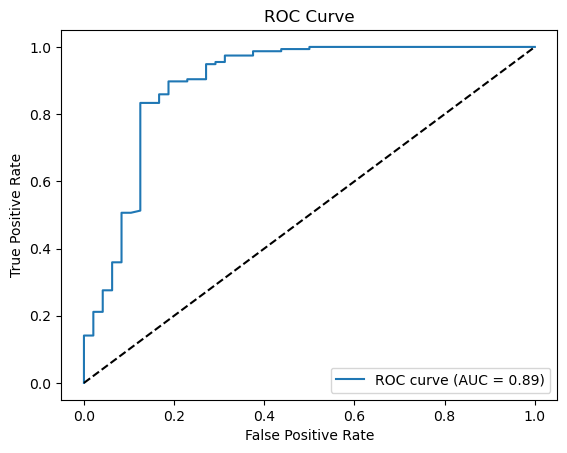

Test Accuracy: 0.8970588235294118, AUC: 0.8937633547008548
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 185.15986739844084, Train Acc: 0.8105456774984672
Validation Acc: 0.8921568627450981, Val Count: 204
Model saved!
Epoch 1
Train Loss: 134.15647345036268, Train Acc: 0.8773758430410791
Validation Acc: 0.9068627450980392, Val Count: 204
Model saved!
Epoch 2
Train Loss: 113.41540749743581, Train Acc: 0.8957694665849172
Validation Acc: 0.8921568627450981, Val Count: 204
Epoch 3
Train Loss: 98.20584636926651, Train Acc: 0.911710606989577
Validation Acc: 0.9117647058823529, Val Count: 204
Model saved!
Epoch 4
Train Loss: 85.34513256326318, Train Acc: 0.9276517473942366
Validation Acc: 0.9117647058823529, Val Count: 204
Epoch 5
Train Loss: 73.67865972965956, Train Acc: 0.9411404046597179
Validation Acc: 0.9166666666666666, Val Count: 204
Model saved!
Epoch 6
Train L

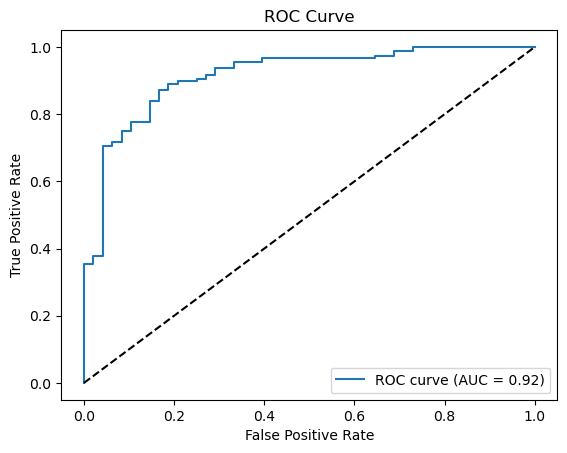

Test Accuracy: 0.8774509803921569, AUC: 0.9155982905982906
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 185.54123060405254, Train Acc: 0.7958307786633967
Validation Acc: 0.8578431372549019, Val Count: 204
Model saved!
Epoch 1
Train Loss: 131.86318326741457, Train Acc: 0.8810545677498467
Validation Acc: 0.8872549019607843, Val Count: 204
Model saved!
Epoch 2
Train Loss: 113.07125407457352, Train Acc: 0.9006744328632741
Validation Acc: 0.8921568627450981, Val Count: 204
Model saved!
Epoch 3
Train Loss: 100.56926946341991, Train Acc: 0.9129368485591661
Validation Acc: 0.9166666666666666, Val Count: 204
Model saved!
Epoch 4
Train Loss: 86.73197699338198, Train Acc: 0.9227467811158798
Validation Acc: 0.9166666666666666, Val Count: 204
Epoch 5
Train Loss: 76.61897774413228, Train Acc: 0.9337829552421827
Validation Acc: 0.8774509803921569, Val Count: 204
Epoch 6
Train

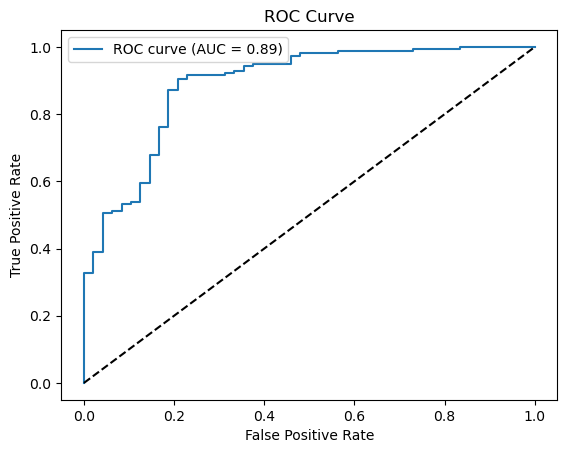

Test Accuracy: 0.8529411764705882, AUC: 0.8883547008547007


In [18]:
for i in range(2025,2028):
    args = create_args('BBBP','BBBP'+str(i),i)
    train(args)
    test(args)

Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 194.55559044331312, Train Acc: 0.7872470876762723
Validation Acc: 0.8235294117647058, Val Count: 204
Model saved!
Epoch 1
Train Loss: 164.84664899855852, Train Acc: 0.8289393010423053
Validation Acc: 0.8186274509803921, Val Count: 204
Epoch 2
Train Loss: 153.48031245917082, Train Acc: 0.8516247700797057
Validation Acc: 0.8431372549019608, Val Count: 204
Model saved!
Epoch 3
Train Loss: 149.43670466169715, Train Acc: 0.8497854077253219
Validation Acc: 0.8382352941176471, Val Count: 204
Epoch 4
Train Loss: 146.59152908995748, Train Acc: 0.8571428571428571
Validation Acc: 0.8382352941176471, Val Count: 204
Epoch 5
Train Loss: 140.91121263802052, Train Acc: 0.8608215818516247
Validation Acc: 0.8529411764705882, Val Count: 204
Model saved!
Epoch 6
Train Loss: 138.69331826269627, Train Acc: 0.8602084610668301
Validation Acc: 0.85294

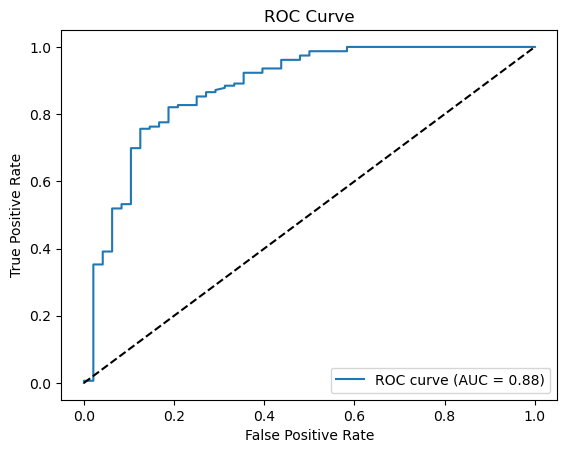

Test Accuracy: 0.8676470588235294, AUC: 0.8792067307692307
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 191.1243295967579, Train Acc: 0.7884733292458614
Validation Acc: 0.8333333333333334, Val Count: 204
Model saved!
Epoch 1
Train Loss: 168.1950998902321, Train Acc: 0.8295524218271
Validation Acc: 0.8431372549019608, Val Count: 204
Model saved!
Epoch 2
Train Loss: 159.0508824661374, Train Acc: 0.841814837522992
Validation Acc: 0.8431372549019608, Val Count: 204
Epoch 3
Train Loss: 155.69992845505476, Train Acc: 0.8442673206621705
Validation Acc: 0.8333333333333334, Val Count: 204
Epoch 4
Train Loss: 148.8158908635378, Train Acc: 0.8540772532188842
Validation Acc: 0.8578431372549019, Val Count: 204
Model saved!
Epoch 5
Train Loss: 146.7041080482304, Train Acc: 0.8559166155732679
Validation Acc: 0.8529411764705882, Val Count: 204
Epoch 6
Train Loss: 142.60188258066773, Tra

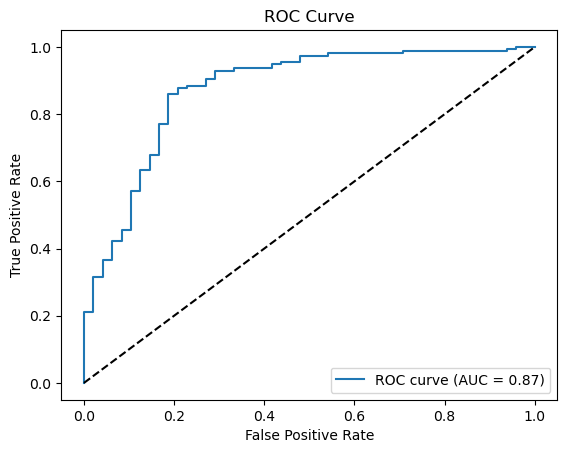

Test Accuracy: 0.8578431372549019, AUC: 0.873263888888889
Data loaded from ./preprocessed_data/BBBP.pkl
train:val:test = 1631:204:204
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 194.7104861214757, Train Acc: 0.7841814837522992
Validation Acc: 0.8480392156862745, Val Count: 204
Model saved!
Epoch 1
Train Loss: 159.71015626192093, Train Acc: 0.8399754751686083
Validation Acc: 0.8529411764705882, Val Count: 204
Model saved!
Epoch 2
Train Loss: 151.40082228183746, Train Acc: 0.8546903740036788
Validation Acc: 0.8627450980392157, Val Count: 204
Model saved!
Epoch 3
Train Loss: 146.01377088204026, Train Acc: 0.8497854077253219
Validation Acc: 0.8578431372549019, Val Count: 204
Epoch 4
Train Loss: 144.06093711778522, Train Acc: 0.8559166155732679
Validation Acc: 0.8480392156862745, Val Count: 204
Epoch 5
Train Loss: 141.73275508359075, Train Acc: 0.8608215818516247
Validation Acc: 0.8529411764705882, Val Count: 204
Epoch 6
Train Loss: 134.839439623057

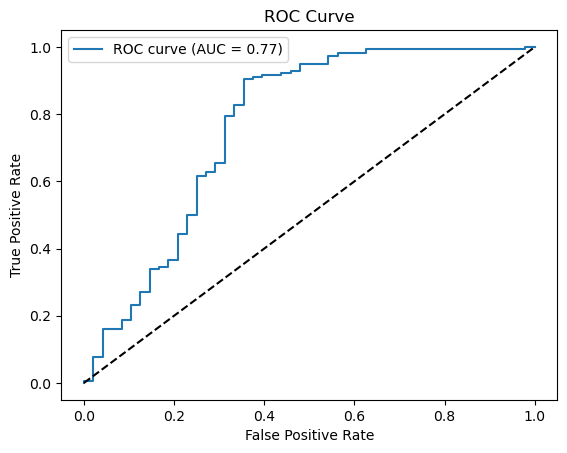

Test Accuracy: 0.8529411764705882, AUC: 0.765758547008547


In [24]:
for i in range(2025,2028):
    args = create_args('BBBP','Random_BBBP'+str(i),i)
    train(args,pretrain_model=' ')
    test(args)

## Tox21

Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 311.7755126617849, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 262.02309423312545, Train Acc: 0.9381219468065859
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 227.16069458052516, Train Acc: 0.9417405464085399
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 183.65810164622962, Train Acc: 0.952053555274109
Validation Acc: 0.9218523878437048, Val Count: 691
Epoch 4
Train Loss: 146.53549926914275, Train Acc: 0.9616428442192871
Validation Acc: 0.9204052098408104, Val Count: 691
Epoch 5
Train Loss: 118.14046431146562, Train Acc: 0.9715939931246608
Validation Acc: 0.9218523878437048, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
finish tarining!!!
Fine-tuned model loaded from checkpo

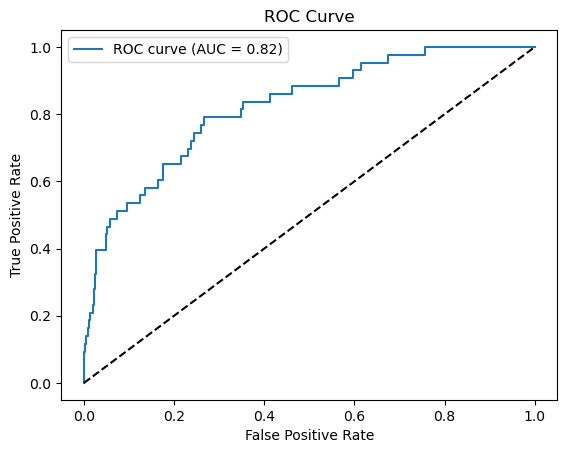

Test Accuracy: 0.9377713458755427, AUC: 0.8227820844099913
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 311.3340464346111, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 262.4138338100165, Train Acc: 0.9388456667269767
Validation Acc: 0.9392185238784371, Val Count: 691
Model saved!
Epoch 2
Train Loss: 227.05978345312178, Train Acc: 0.9437307761896147
Validation Acc: 0.934876989869754, Val Count: 691
Epoch 3
Train Loss: 181.86143163684756, Train Acc: 0.9524154152343043
Validation Acc: 0.9392185238784371, Val Count: 691
Epoch 4
Train Loss: 138.9161032261327, Train Acc: 0.9670707436222182
Validation Acc: 0.9232995658465991, Val Count: 691
Epoch 5
Train Loss: 109.74137930385768, Train Acc: 0.9752125927266148
Validation Acc: 0.9421128798842258, Val Count: 691
Model saved!
Epoch 6
Train Loss: 91.2972

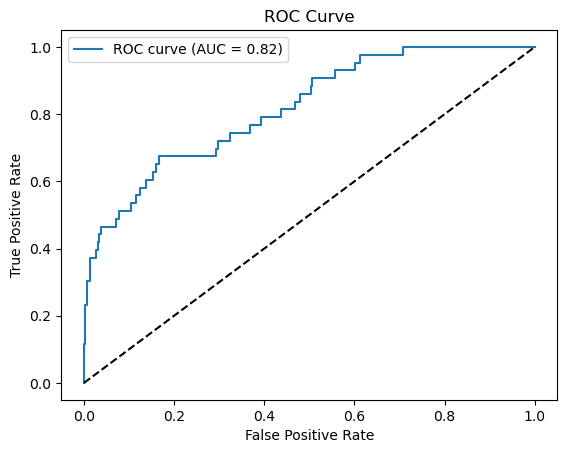

Test Accuracy: 0.9493487698986975, AUC: 0.8171834625322997
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 300.5241929721087, Train Acc: 0.937398226886195
Validation Acc: 0.9392185238784371, Val Count: 691
Model saved!
Epoch 1
Train Loss: 253.31727287359536, Train Acc: 0.9390265967070743
Validation Acc: 0.9435600578871202, Val Count: 691
Model saved!
Epoch 2
Train Loss: 212.31052573304623, Train Acc: 0.9448163560702009
Validation Acc: 0.9421128798842258, Val Count: 691
Epoch 3
Train Loss: 170.27007398940623, Train Acc: 0.9578433146372354
Validation Acc: 0.934876989869754, Val Count: 691
Epoch 4
Train Loss: 136.0646391455084, Train Acc: 0.9670707436222182
Validation Acc: 0.9319826338639653, Val Count: 691
Epoch 5
Train Loss: 106.37856075633317, Train Acc: 0.976298172607201
Validation Acc: 0.9247467438494935, Val Count: 691
Epoch 6
Train Loss: 87.50791766121984, Tr

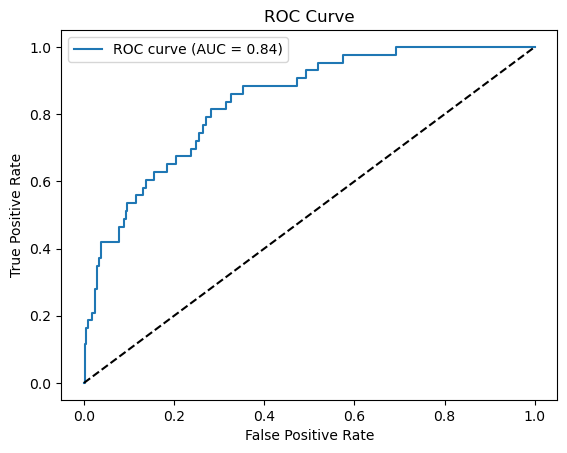

Test Accuracy: 0.9363241678726484, AUC: 0.8378194085558427


In [20]:
for i in range(2025,2028):
    args = create_args('Tox21','Tox21'+str(i),i)
    train(args)
    test(args)

Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 313.0444356575608, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 299.37472326494753, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 296.37208172492683, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 293.22580377198756, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 4
Train Loss: 290.6798210721463, Train Acc: 0.937398226886195
Validation Acc: 0.934876989869754, Val Count: 691
Epoch 5
Train Loss: 288.62433632463217, Train Acc: 0.9377600868463905
Validation Acc: 0.9377713458755427, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
finish tarining!!!
Fine-tuned model loaded from checkpoints_test/Ra

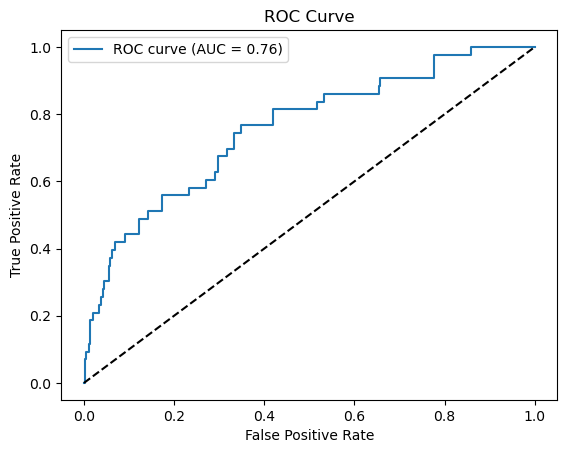

Test Accuracy: 0.9377713458755427, AUC: 0.7564599483204134
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 313.3684264048934, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 298.63277168758214, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 296.94881824962795, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 292.8407892603427, Train Acc: 0.937398226886195
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 4
Train Loss: 291.5434790402651, Train Acc: 0.937398226886195
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 5
Train Loss: 287.7699490059167, Train Acc: 0.9379410168264881
Validation Acc: 0.9377713458755427, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
finish tar

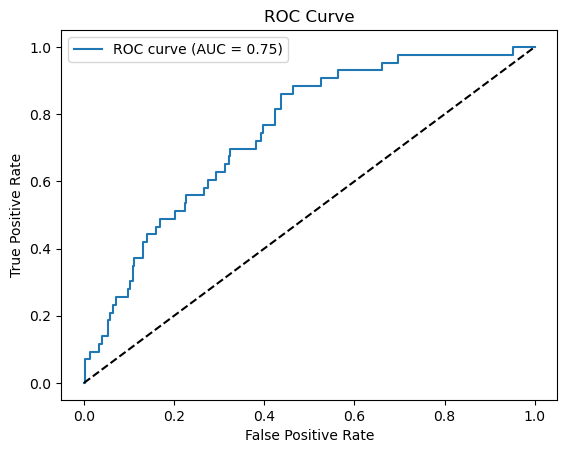

Test Accuracy: 0.9377713458755427, AUC: 0.747595463680735
Data loaded from ./preprocessed_data/Tox21.pkl
train:val:test = 5527:691:691
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 309.29199888929725, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Model saved!
Epoch 1
Train Loss: 295.8761908747256, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 2
Train Loss: 292.82511523738503, Train Acc: 0.9375791568662928
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 3
Train Loss: 291.08241714537144, Train Acc: 0.9372172969060973
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 4
Train Loss: 286.2309302389622, Train Acc: 0.9372172969060973
Validation Acc: 0.9377713458755427, Val Count: 691
Epoch 5
Train Loss: 284.9994629789144, Train Acc: 0.9368554369459019
Validation Acc: 0.9377713458755427, Val Count: 691
No improvement in the last 5 epochs. Training stopped.
finish t

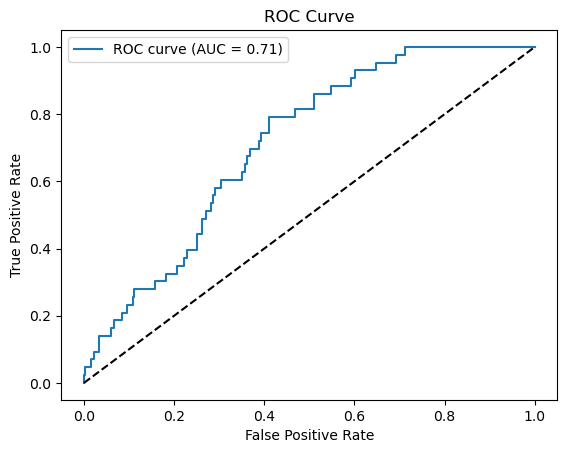

Test Accuracy: 0.9377713458755427, AUC: 0.7116350846971002


In [25]:
for i in range(2025,2028):
    args = create_args('Tox21','Random_Tox21'+str(i),i)
    train(args,pretrain_model=' ')
    test(args)

## HIV

Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 1041.210635622032, Train Acc: 0.9674448294729163
Validation Acc: 0.9676635059567226, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 870.7893327325583, Train Acc: 0.9721563620888808
Validation Acc: 0.9679066374908826, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 774.2393170399591, Train Acc: 0.9743145479968387
Validation Acc: 0.9671772428884027, Val Count: 4113
Epoch 3
Train Loss: 688.9318357408047, Train Acc: 0.9766247188278923
Validation Acc: 0.9652321906151228, Val Count: 4113
Epoch 4
Train Loss: 623.6443222472444, Train Acc: 0.9786917137819928
Validation Acc: 0.9666909798200827, Val Count: 4113
Epoch 5
Train Loss: 560.7566775684245, Train Acc: 0.9808195027053316
Validation Acc: 0.9659615852176027, Val Count: 4113
Epoch 6
Train Loss: 497.721124174539, Train Acc: 0.9833728494133382
Validation Acc: 0.96207148

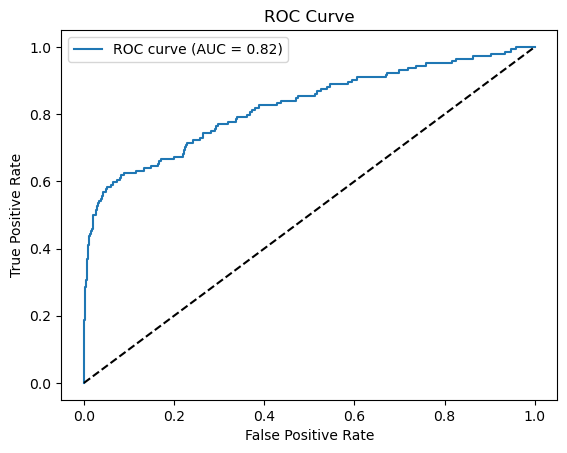

Test Accuracy: 0.9705810843666424, AUC: 0.8229560342655581
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 1060.1806165575981, Train Acc: 0.966897683749772
Validation Acc: 0.9683929005592026, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 885.2672780863941, Train Acc: 0.9713356435041643
Validation Acc: 0.9720398735716023, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 796.499698731117, Train Acc: 0.9746489148276491
Validation Acc: 0.9725261366399222, Val Count: 4113
Model saved!
Epoch 3
Train Loss: 724.139057575725, Train Acc: 0.9765943218432731
Validation Acc: 0.9642596644784829, Val Count: 4113
Epoch 4
Train Loss: 655.3741224762052, Train Acc: 0.978509331874278
Validation Acc: 0.9700948212983224, Val Count: 4113
Epoch 5
Train Loss: 592.727440206334, Train Acc: 0.9802419599975682
Validation Acc: 0.9717967420374423, Val Count: 4113
Epoch 6
Train Loss: 535.07

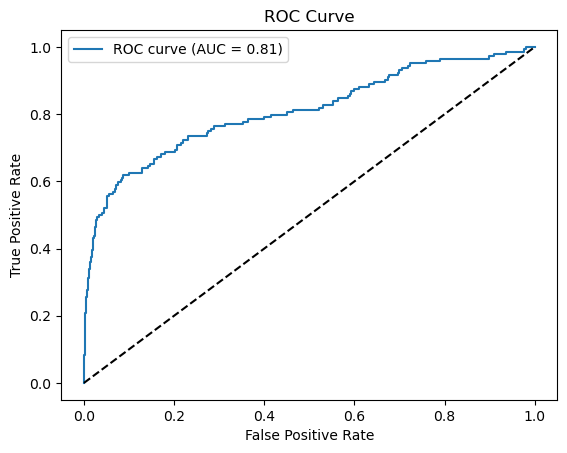

Test Accuracy: 0.9686360320933625, AUC: 0.8101239466980207
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
Pre-trained model loaded from ChemBart_model/model_1200.pth
start tarining!
Epoch 0
Train Loss: 1034.8018110888079, Train Acc: 0.9675968143960119
Validation Acc: 0.9705810843666424, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 854.8728185109794, Train Acc: 0.9713660404887835
Validation Acc: 0.9698516897641624, Val Count: 4113
Epoch 2
Train Loss: 763.2705576429144, Train Acc: 0.9740409751352666
Validation Acc: 0.9688791636275225, Val Count: 4113
Epoch 3
Train Loss: 687.9084544014186, Train Acc: 0.9768678947048453
Validation Acc: 0.9691222951616825, Val Count: 4113
Epoch 4
Train Loss: 606.0180581747554, Train Acc: 0.9788436987050885
Validation Acc: 0.9654753221492828, Val Count: 4113
Epoch 5
Train Loss: 531.2996569876559, Train Acc: 0.9820353820900967
Validation Acc: 0.9649890590809628, Val Count: 4113
No improvement in the last 5 epochs. Training s

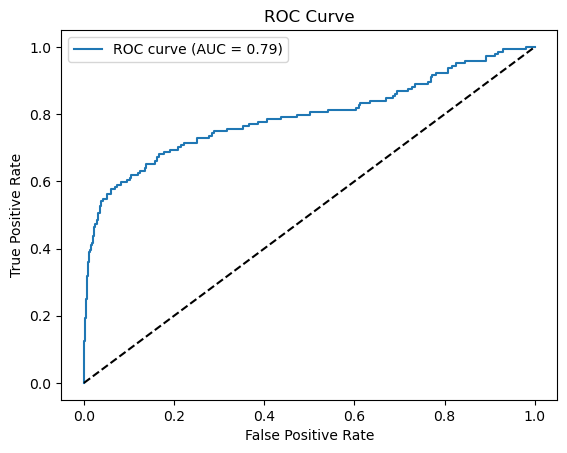

Test Accuracy: 0.9683929005592026, AUC: 0.7923822821309594


In [26]:
for i in range(2025,2028):
    args = create_args('HIV','HIV'+str(i),i)
    train(args)
    test(args)

Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 1190.7632453460246, Train Acc: 0.9652258495957201
Validation Acc: 0.9664478482859227, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 1154.4047580771148, Train Acc: 0.9658337892881026
Validation Acc: 0.9664478482859227, Val Count: 4113
Epoch 2
Train Loss: 1136.8220766987652, Train Acc: 0.9658945832573409
Validation Acc: 0.9662047167517627, Val Count: 4113
Epoch 3
Train Loss: 1112.5243186559528, Train Acc: 0.9662289500881512
Validation Acc: 0.9662047167517627, Val Count: 4113
Epoch 4
Train Loss: 1088.7338999602944, Train Acc: 0.9663809350112469
Validation Acc: 0.9671772428884027, Val Count: 4113
Model saved!
Epoch 5
Train Loss: 1075.0521766077727, Train Acc: 0.9669888747036294
Validation Acc: 0.9654753221492828, Val Count: 4113
Epoch 6
Train Loss: 1054.0011466294527, Train Acc: 0.9671712566113442
Validation Acc: 0.9642596644

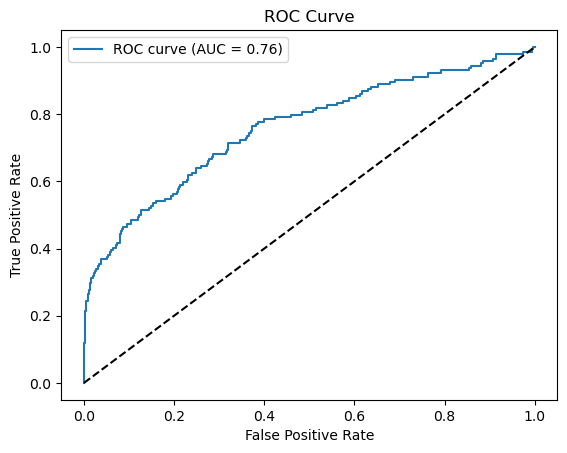

Test Accuracy: 0.9681497690250426, AUC: 0.7580922286610117
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 1184.6718065403402, Train Acc: 0.9655602164265304
Validation Acc: 0.9652321906151228, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 1150.841928768903, Train Acc: 0.9662289500881512
Validation Acc: 0.9645027960126429, Val Count: 4113
Epoch 2
Train Loss: 1135.766985727474, Train Acc: 0.9656514073803879
Validation Acc: 0.9654753221492828, Val Count: 4113
Model saved!
Epoch 3
Train Loss: 1118.0036542974412, Train Acc: 0.9661073621496747
Validation Acc: 0.9649890590809628, Val Count: 4113
Epoch 4
Train Loss: 1097.46662437357, Train Acc: 0.9662593470727704
Validation Acc: 0.9647459275468028, Val Count: 4113
Epoch 5
Train Loss: 1077.5725556183606, Train Acc: 0.9663505380266277
Validation Acc: 0.9659615852176027, Val Count: 4113
Model saved!
Epoch 6
Train Loss: 1059.59240

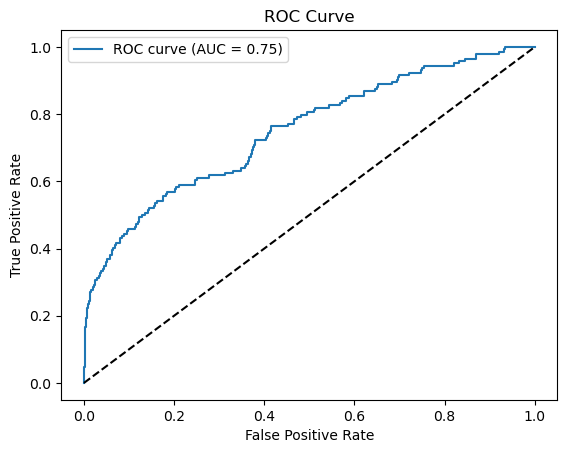

Test Accuracy: 0.9664478482859227, AUC: 0.7490569272976679
Data loaded from ./preprocessed_data/HIV.pkl
train:val:test = 32898:4113:4113
No checkpoint found. Using random initialization.
start tarining!
Epoch 0
Train Loss: 1195.6035789437592, Train Acc: 0.9651042616572436
Validation Acc: 0.9652321906151228, Val Count: 4113
Model saved!
Epoch 1
Train Loss: 1155.1920634619892, Train Acc: 0.9655298194419114
Validation Acc: 0.9662047167517627, Val Count: 4113
Model saved!
Epoch 2
Train Loss: 1140.8783302186057, Train Acc: 0.9655602164265304
Validation Acc: 0.9645027960126429, Val Count: 4113
Epoch 3
Train Loss: 1124.7640862530097, Train Acc: 0.9659857742111982
Validation Acc: 0.9659615852176027, Val Count: 4113
Epoch 4
Train Loss: 1097.1230611363426, Train Acc: 0.9660161711958174
Validation Acc: 0.9659615852176027, Val Count: 4113
Epoch 5
Train Loss: 1077.4980749227107, Train Acc: 0.9663809350112469
Validation Acc: 0.9669341113542427, Val Count: 4113
Model saved!
Epoch 6
Train Loss: 1059.9

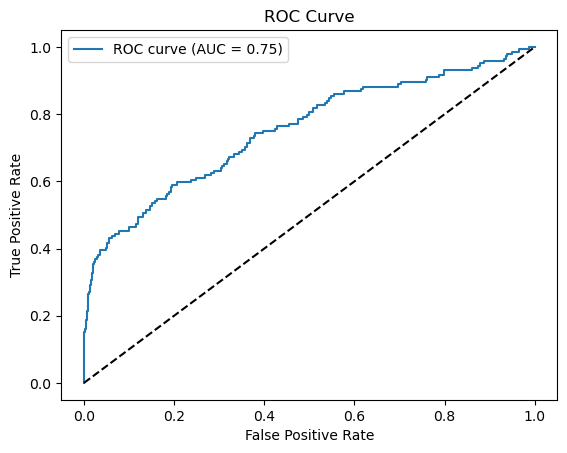

Test Accuracy: 0.9691222951616825, AUC: 0.7522920690910109


In [27]:
for i in range(2025,2028):
    args = create_args('HIV','Random_HIV'+str(i),i)
    train(args,pretrain_model=' ')
    test(args)

## plt 

In [11]:
from sklearn.manifold import TSNE

def create_args(dataset,ftmodel,premodel,device):

    sys.argv = sys.argv[:1] + [arg for arg in sys.argv[1:] if not arg.startswith('--f=')]

    parser = argparse.ArgumentParser(description='Process some integers.')
    parser.add_argument('--dataset', type=str, default=dataset,
                        help='The name of the dataset (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--ftmodel', type=str, default=ftmodel,
                        help='The name of the ftmodel (BBBP, HIV, BACE, Tox21, ClinTox)')
    parser.add_argument('--premodel', type=str, default=premodel,
                        help='The name of the ftmodel (ChemBart_MIT_n,ChemBart_FULL_n)')
    parser.add_argument('--device', type=str, default=device,
                        help='The name of the ftmodel ("cuda:n")')
    args = parser.parse_args()
    return args

def draw(args):
    pre_data = PropertyPreData(args)
    pre_data.process()
    post_data = checkmol(pre_data)
    embs = []
    properties = []

    model = MolProperty_cls(2,args.ftmodel,args.premodel,args.device)
    for item in post_data:
        try:
            emb = model.transform([item[0] + "<end>"])
            embs.append(emb)
            properties.append(item[1])
        except Exception as e:
            print(f"Error processing item {item[0]}: {e}")
    # 将embs和properties转为正确的数据格式
    embs = np.concatenate(embs, axis=0)  # 将embs转换为NumPy数组
    properties = np.array(properties)  # 将properties转换为NumPy数组

    non_binding_count = np.sum(properties == 0)
    binding_count = np.sum(properties == 1)
    print(f"non-binding count: {non_binding_count}")
    print(f"binding count: {binding_count}")

    labels = properties
    thresholds = [0.5]
    if args.dataset == 'BACE':
        legend = ['non-active', 'active']
        colors = [(73/255, 45/255, 34/255),(1/255, 132/255, 127/255)]
    elif args.dataset == 'BBBP':
        legend = ['non-permeable', 'permeable']
        colors = ['maroon', 'gold']
    #colors = [(73/255, 45/255, 34/255),'gold']

    print('calculating TSNE embeddings')
    tsne = TSNE(random_state=0).fit_transform(embs)
    for i in range(len(thresholds) + 1):
        plt.scatter(tsne[labels == i, 0], tsne[labels == i, 1], s=3, c=[colors[i]])
    plt.legend(legend, loc='best', fontsize=12, ncol=1)
    #放大横纵坐标字号
    plt.xticks(fontsize=14)  # 横坐标字号
    plt.yticks(fontsize=14)
    plt.show()

processing BACE dataset
Original BACE has 1513 data, start checking
Finish checking molecules, now BACE has 1513 data
pre-trained model ChemBart_model/model_1200.pth
non-binding count: 822
binding count: 691
calculating TSNE embeddings


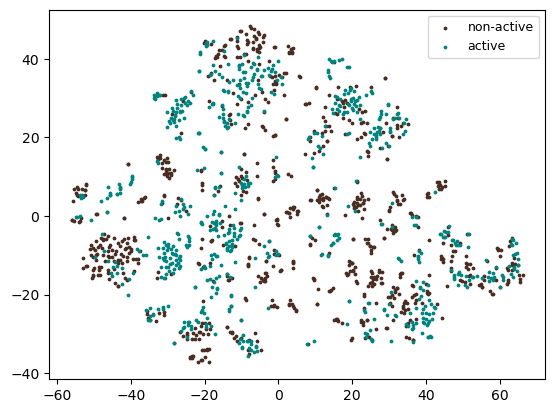

In [57]:
# cluster before fine-tuning
args = create_args('BACE',ftmodel=' ',premodel='model_1200',device='cuda:0')
draw(args)

processing BACE dataset
Original BACE has 1513 data, start checking
Finish checking molecules, now BACE has 1513 data
fine-tuned model checkpoints/BACE2025.pth
non-binding count: 822
binding count: 691
calculating TSNE embeddings


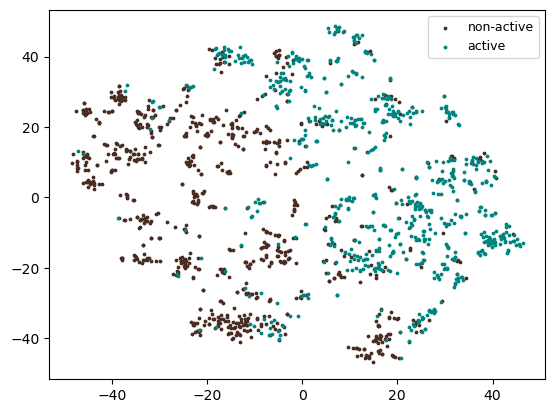

In [58]:
# cluster before fine-tuning
args = create_args('BACE',ftmodel='BACE2025',premodel='model_1200',device='cuda:0')
draw(args)

processing BACE dataset
Original BACE has 1513 data, start checking
Finish checking molecules, now BACE has 1513 data
pre-trained model ChemBart_model/ChemBart_MIT_6.pth
non-binding count: 822
binding count: 691
calculating TSNE embeddings


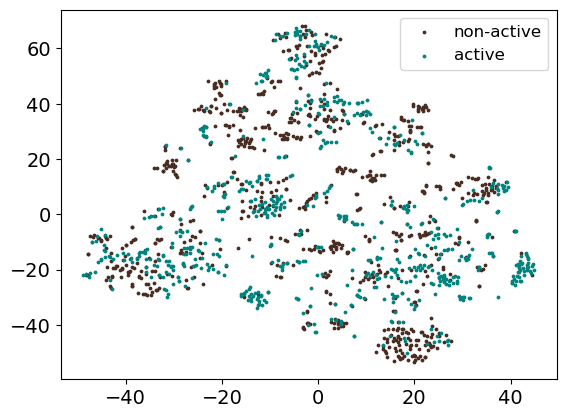

In [12]:
# cluster before fine-tuning
args = create_args('BACE',ftmodel=' ',premodel='ChemBart_MIT_6',device='cuda:0')
draw(args)

processing BACE dataset
Original BACE has 1513 data, start checking
Finish checking molecules, now BACE has 1513 data
fine-tuned model checkpoints/BACE.pth
non-binding count: 822
binding count: 691
calculating TSNE embeddings


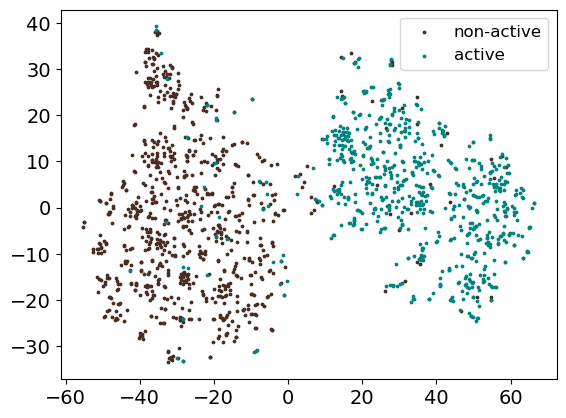

In [13]:
# cluster after fine-tuning
args = create_args('BACE',ftmodel='BACE',premodel='ChemBart_MIT_6',device='cuda:0')
draw(args)

processing BBBP dataset
Original BBBP has 2050 data, start checking
Finish checking molecules, now BBBP has 2039 data
pre-trained model ChemBart_model/ChemBart_MIT_6.pth
non-binding count: 479
binding count: 1560
calculating TSNE embeddings


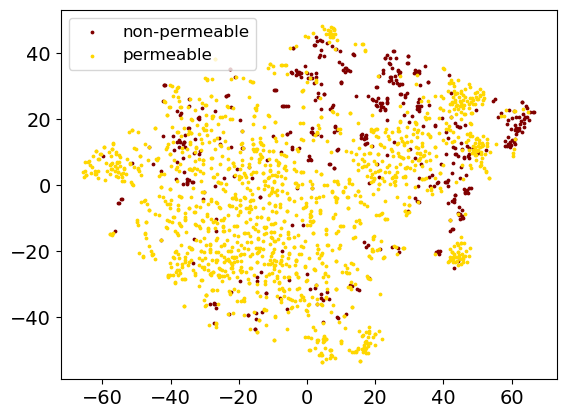

In [14]:
# cluster before fine-tuning
args = create_args('BBBP',ftmodel=' ',premodel='ChemBart_MIT_6',device='cuda:0')
draw(args)

processing BBBP dataset
Original BBBP has 2050 data, start checking
Finish checking molecules, now BBBP has 2039 data
fine-tuned model checkpoints/BBBP.pth
non-binding count: 479
binding count: 1560
calculating TSNE embeddings


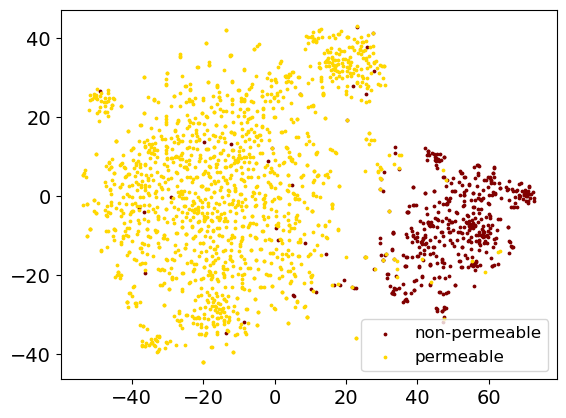

In [15]:
# cluster after fine-tuning
args = create_args('BBBP',ftmodel='BBBP',premodel='ChemBart_MIT_6',device='cuda:0')
draw(args)